# POC SOC Triage — 03 Modèles ML

**Objectif** : entraîner deux modèles complémentaires sur les features produites par `02_feature_engineering.ipynb`.

- **Isolation Forest** (non-supervisé) : détecte les incidents anormaux sans labels → simule le démarrage à froid (cold start) avant qu'un historique de qualification suffisant soit disponible.
- **XGBoost** (supervisé) : classifie TP/BP/FP avec les labels GUIDE → modèle de production. Pondération via `compute_sample_weight('balanced')` (SMOTE écarté pour éviter la synthèse de patterns d'attaque artificiels). Hyperparamètres ajustés manuellement : `n_estimators=400`, `max_depth=5`, `learning_rate=0.05`, `min_child_weight=3`, `gamma=0.5`.

**Split** : 80/20 via `StratifiedGroupKFold` (random_state=42, fold 1 sur 5) groupé sur `OrgId` — aucune organisation présente simultanément dans train (26 813 incidents) et test (3 187 incidents).

**Inputs** (produits par `02_`) :
- `features_ml.parquet` — 83 features ML + IncidentId + OrgId + target
- `encoder_alert_title.parquet`, `encoder_category.parquet`, `encoder_detector.parquet` — tables de target encoding
- `global_rates.pkl` — taux globaux de fallback

**Outputs** :
- `predictions_full.csv` — 30 000 incidents prédits (dataset complet, simule un datalake SOC en production)
- `predictions_sample.csv` — 500 incidents extraits du test set pour la démo Streamlit (`05_demo_app.py`)
- `models/isolation_forest.pkl` — modèle non-supervisé + scaler
- `models/xgboost_booster.json` — booster XGBoost natif (chargé par `04_xai.ipynb`)
- `models/xgboost_model.pkl` — wrapper XGBoost sérialisé
- `models/inference_config.pkl` — FEATURE_COLS, taux globaux et seuils (chargé par `04_` et `05_`)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              precision_recall_curve, fbeta_score)
import xgboost as xgb

DATA_DIR  = Path('data')
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Librairies OK')
print(f'XGBoost version: {xgb.__version__}')

Librairies OK
XGBoost version: 2.1.1


## 1. Chargement et split train/test

In [19]:
# Chargement depuis le parquet (dtypes int8 préservés, plus rapide que CSV)
df = pd.read_parquet(DATA_DIR / 'features_ml.parquet')

# OrgId est conservé dans features_ml pour le split stratifié par organisation.
# Il est exclu de FEATURE_COLS — ce n'est pas une feature ML, c'est un identifiant
# de groupe utilisé uniquement pour s'assurer qu'aucune organisation n'est
# à la fois dans le train set et le test set (évite le leakage organisationnel).
FEATURE_COLS = [c for c in df.columns if c not in ['IncidentId', 'target', 'OrgId']]
X      = df[FEATURE_COLS].values
y      = df['target'].values
groups = df['OrgId'].values

print(f'Dataset : {len(df):,} incidents × {len(FEATURE_COLS)} features')
print(f'Distribution cible : {dict(pd.Series(y).value_counts().rename({0:"FP", 1:"BP", 2:"TP"}))}')
print(f'Nb organisations uniques : {df["OrgId"].nunique():,}')


Dataset : 30,000 incidents × 83 features
Distribution cible : {'BP': 13869, 'FP': 9514, 'TP': 6617}
Nb organisations uniques : 3,390


In [20]:
# --- Option A : chargement des encodeurs appris en 02_feature_engineering
# Ces tables permettront d'encoder les nouvelles alertes SIEM sans recalculer
# sur les données de test (évite le leakage)

encoder_alert_title = pd.read_parquet(DATA_DIR / 'encoder_alert_title.parquet')
encoder_category    = pd.read_parquet(DATA_DIR / 'encoder_category.parquet')
encoder_detector    = pd.read_parquet(DATA_DIR / 'encoder_detector.parquet')

with open(DATA_DIR / 'global_rates.pkl', 'rb') as f:
    global_rates = pickle.load(f)

print('Encodeurs chargés :')
print(f'  alert_title : {len(encoder_alert_title):,} titres')
print(f'  category    : {len(encoder_category):,} catégories')
print(f'  detector    : {len(encoder_detector):,} détecteurs')
print(f'  global_rates: TP={global_rates["global_tp_rate"]:.3f} | '
      f'FP={global_rates["global_fp_rate"]:.3f} | '
      f'BP={global_rates["global_bp_rate"]:.3f}')

# Fonction d'encodage réutilisable pour l'inférence sur nouvelles alertes SIEM
def encode_new_alerts(df_new):
    """
    Applique les encodeurs appris sur le train set à un nouveau DataFrame d'alertes.
    df_new doit contenir : top_alert_title, top_category, top_detector, OrgId
    Retourne df_new enrichi des colonnes de target encoding.
    """
    df_enc = df_new.copy()

    # Alert title
    df_enc = df_enc.merge(encoder_alert_title, left_on='top_alert_title',
                          right_index=True, how='left')
    # Category
    df_enc = df_enc.merge(encoder_category, left_on='top_category',
                          right_index=True, how='left')
    # Detector
    df_enc = df_enc.merge(encoder_detector, left_on='top_detector',
                          right_index=True, how='left')

    # Fallback : nouvelles valeurs inconnues → taux globaux
    for col, val in [
        ('alert_title_tp_rate', global_rates['global_tp_rate']),
        ('alert_title_fp_rate', global_rates['global_fp_rate']),
        ('alert_title_bp_rate', global_rates['global_bp_rate']),
        ('category_tp_rate',    global_rates['global_tp_rate']),
        ('category_fp_rate',    global_rates['global_fp_rate']),
        ('category_bp_rate',    global_rates['global_bp_rate']),
        ('detector_tp_rate',    global_rates['global_tp_rate']),
        ('detector_fp_rate',    global_rates['global_fp_rate']),
        ('detector_bp_rate',    global_rates['global_bp_rate']),
                ]:
        if col in df_enc.columns:
            df_enc[col] = df_enc[col].fillna(val)

    return df_enc

print('\nFonction encode_new_alerts() prête pour l\'inférence SIEM ✓')

Encodeurs chargés :
  alert_title : 4,868 titres
  category    : 18 catégories
  detector    : 207 détecteurs
  global_rates: TP=0.221 | FP=0.317 | BP=0.462

Fonction encode_new_alerts() prête pour l'inférence SIEM ✓


In [21]:
# Split stratifié par OrgId : aucune org ne doit être dans train ET test
# → évite le leakage organisationnel
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# On prend le premier fold : 80% train, 20% test
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train : {len(X_train):,} incidents')
print(f'Test  : {len(X_test):,} incidents')
print(f'Train distribution : {dict(pd.Series(y_train).value_counts().rename({0:"FP",1:"BP",2:"TP"}))}')
print(f'Test  distribution : {dict(pd.Series(y_test).value_counts().rename({0:"FP",1:"BP",2:"TP"}))}')

Train : 26,813 incidents
Test  : 3,187 incidents
Train distribution : {'BP': 12389, 'FP': 8892, 'TP': 5532}
Test  distribution : {'BP': 1480, 'TP': 1085, 'FP': 622}


## 2. Modèle 1 — Isolation Forest (non-supervisé)

**Principe** : entraîné *sans labels* sur les incidents du train set. Il attribue un score d'anomalie à chaque incident. Les incidents les plus anormaux sont prioritaires pour l'analyste.

**Interprétation bancaire** : "Au démarrage, avant d'avoir des labels validés, le système peut déjà trier les alertes les plus atypiques."

In [22]:
print('Entraînement Isolation Forest (sans labels)...')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # hypothèse : ~15% d'incidents vraiment anormaux
    max_samples='auto',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso_forest.fit(X_train)  # PAS de y_train !

# Score d'anomalie : plus négatif = plus anormal
# On renverse et normalise entre 0 et 100
anomaly_scores_train = iso_forest.decision_function(X_train)
anomaly_scores_test = iso_forest.decision_function(X_test)

# Normalisation 0-100 (100 = le plus anormal)
from sklearn.preprocessing import MinMaxScaler
scaler_iso = MinMaxScaler()
all_scores = np.concatenate([anomaly_scores_train, anomaly_scores_test])
scaler_iso.fit(all_scores.reshape(-1, 1))

iso_score_train = 100 - scaler_iso.transform(anomaly_scores_train.reshape(-1, 1)).flatten() * 100
iso_score_test  = 100 - scaler_iso.transform(anomaly_scores_test.reshape(-1, 1)).flatten() * 100

print(f'Score anomalie moyen par grade réel (test set) :')
for grade_code, grade_name in [(2, 'TP'), (1, 'BP'), (0, 'FP')]:
    mask = y_test == grade_code
    print(f'  {grade_name}: {iso_score_test[mask].mean():.1f} / 100')

print('\n→ Si les TP ont un score significativement plus élevé que les FP, le modèle est utile.')

Entraînement Isolation Forest (sans labels)...
Score anomalie moyen par grade réel (test set) :
  TP: 23.9 / 100
  BP: 13.8 / 100
  FP: 13.8 / 100

→ Si les TP ont un score significativement plus élevé que les FP, le modèle est utile.


/var/folders/fb/n81c_xk9361bflkbqt783n_00000gn/T/ipykernel_31556/2440752590.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=['FP', 'BP', 'TP'], patch_artist=True)


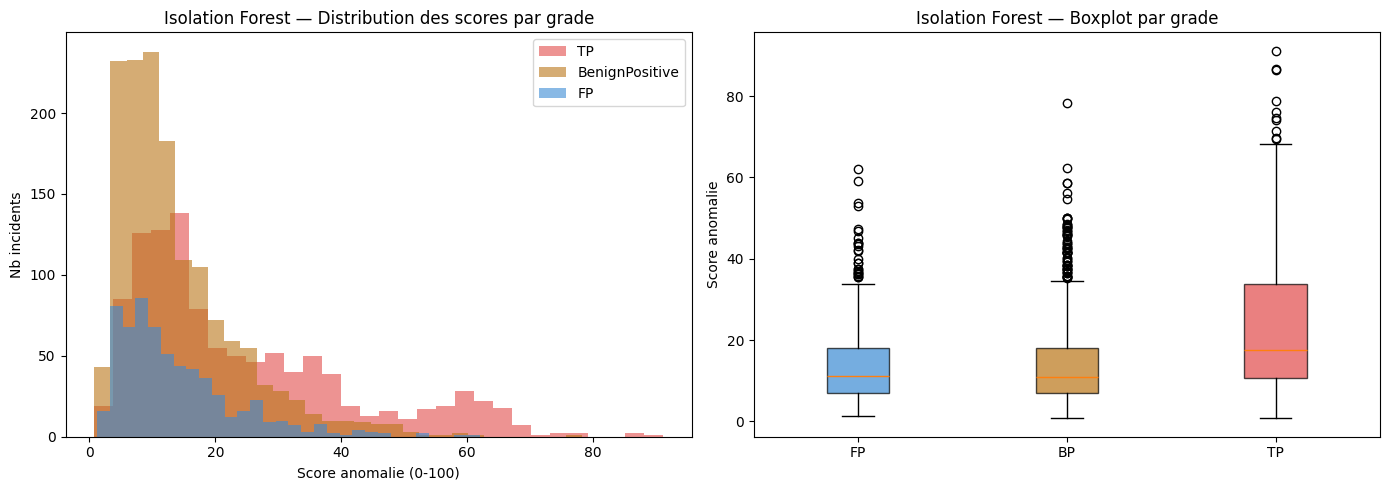

In [23]:
# Visualisation : distribution des scores Isolation Forest par grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_names = {2: 'TP', 1: 'BenignPositive', 0: 'FP'}
colors_grade = {2: '#E24B4A', 1: '#BA7517', 0: '#3B8BD4'}

for grade_code, grade_name in grade_names.items():
    mask = y_test == grade_code
    axes[0].hist(iso_score_test[mask], bins=30, alpha=0.6,
                 label=grade_name, color=colors_grade[grade_code])
axes[0].set_xlabel('Score anomalie (0-100)')
axes[0].set_ylabel('Nb incidents')
axes[0].set_title('Isolation Forest — Distribution des scores par grade')
axes[0].legend()

# Boxplot
data_box = [iso_score_test[y_test == g] for g in [0, 1, 2]]
bp = axes[1].boxplot(data_box, labels=['FP', 'BP', 'TP'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3B8BD4', '#BA7517', '#E24B4A']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Score anomalie')
axes[1].set_title('Isolation Forest — Boxplot par grade')

plt.tight_layout()
plt.savefig(DATA_DIR / 'isolation_forest_scores.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# Évaluation non-supervisée : AUC TP vs reste
# (seule métrique applicable sans labels pendant l'entraînement)
auc_iso = roc_auc_score((y_test == 2).astype(int), iso_score_test)
print(f'AUC-ROC Isolation Forest (TP détection) : {auc_iso:.3f}')
print(f'  → Interprétation : un AUC > 0.60 montre que les incidents TP')
print(f'     ont tendance à avoir un score d\'anomalie plus élevé.')
print(f'  → Random = 0.50, Parfait = 1.00')

# Précision dans le top 20% des alertes
threshold_80 = np.percentile(iso_score_test, 80)
top20_mask = iso_score_test >= threshold_80
precision_top20 = (y_test[top20_mask] == 2).mean()
print(f'\nPrécision TP dans le top 20% alertes (score >= {threshold_80:.0f}) : {precision_top20:.1%}')
print(f'  vs {(y_test == 2).mean():.1%} dans l\'ensemble du dataset')

# Sauvegarde du modèle
joblib.dump({'model': iso_forest, 'scaler': scaler_iso}, MODEL_DIR / 'isolation_forest.pkl')
print(f'\nModèle sauvegardé : models/isolation_forest.pkl')

AUC-ROC Isolation Forest (TP détection) : 0.686
  → Interprétation : un AUC > 0.60 montre que les incidents TP
     ont tendance à avoir un score d'anomalie plus élevé.
  → Random = 0.50, Parfait = 1.00

Précision TP dans le top 20% alertes (score >= 26) : 61.9%
  vs 34.0% dans l'ensemble du dataset

Modèle sauvegardé : models/isolation_forest.pkl


## 3. Modèle 2 — XGBoost (supervisé)

**Principe** : utilise les labels IncidentGrade pour apprendre à distinguer TP/BP/FP. Le déséquilibre des classes est compensé par compute_sample_weight('balanced'), qui pondère chaque exemple inversement à la fréquence de sa classe — alternative préférée à SMOTE (cf. cellule suivante pour la justification).

In [25]:
# ── Gestion du déséquilibre par sample_weight ────────────────────────────────
# Pourquoi pas SMOTE ici ?
# SMOTE génère des points synthétiques pour chaque classe minoritaire.
# Avec 3 classes dont BP à 50%, il crée beaucoup de BP synthétiques qui
# noient le signal TP dans l'entraînement et font chuter le F2-score.
#
# Alternative : sample_weight — chaque exemple réel reçoit un poids inversement
# proportionnel à la fréquence de sa classe. Les TP (22%) reçoivent un poids
# plus élevé que les BP (50%), sans générer de données synthétiques.
# C'est plus stable en multiclasse et préserve la distribution réelle.

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print(f'Distribution train : {dict(pd.Series(y_train).value_counts().rename({0:"FP",1:"BP",2:"TP"}))}')
print(f'Poids moyen par classe :')
for cls, name in [(0,'FP'),(1,'BP'),(2,'TP')]:
    w = sample_weights[y_train == cls].mean()
    print(f'  {name} : {w:.3f}')
print(f'Total train : {len(X_train):,} incidents (données réelles, pas synthétiques)')

# X_train_sm et y_train_sm gardent les mêmes noms pour compatibilité
# avec les cellules suivantes — pas de resampling, juste les poids
X_train_sm, y_train_sm = X_train, y_train


Distribution train : {'BP': 12389, 'FP': 8892, 'TP': 5532}
Poids moyen par classe :
  FP : 1.005
  BP : 0.721
  TP : 1.616
Total train : 26,813 incidents (données réelles, pas synthétiques)


In [26]:
# ── Feature weights — PISTE EXPLORÉE, NON RETENUE ────────────────────────────
# Intention initiale : réduire le poids des features de taux (alert_title_*,
# detector_*) qui dominent le gain XGBoost, pour laisser émerger les features
# sandbox/CMDB dans les explications SHAP.
# STATUT : le vecteur feature_weights calculé ci-dessous N'EST PAS appliqué —
# xgb_model.fit() (cellule suivante) ne le passe pas. XGBoost n'expose pas de
# repondération par feature de ce type au .fit(). Les features de taux restent
# donc à leur poids réel : alert_title_fp_rate ressort feature n°1 (cellule 20),
# ce qui est cohérent et attendu. Cellule conservée pour tracer la démarche.
# Note : org_tp_rate etc. supprimés du 02_ — trop dominants (40-65% du gain).

RATE_FEATURES = [
    'alert_title_tp_rate', 'alert_title_fp_rate', 'alert_title_bp_rate',
    'category_tp_rate', 'category_fp_rate', 'category_bp_rate',
    'detector_tp_rate', 'detector_fp_rate', 'detector_bp_rate',
]
RATE_WEIGHT  = 0.1   # à ajuster : 0.3 (moins restrictif), 0.05 (plus restrictif)
OTHER_WEIGHT = 1.0

feature_weights = np.array([
    RATE_WEIGHT if f in RATE_FEATURES else OTHER_WEIGHT
    for f in FEATURE_COLS
])

print(f'Feature weights définis :')
print(f'  {len([f for f in FEATURE_COLS if f in RATE_FEATURES])} features de taux → poids {RATE_WEIGHT}')
print(f'  {len([f for f in FEATURE_COLS if f not in RATE_FEATURES])} autres features → poids {OTHER_WEIGHT}')

Feature weights définis :
  9 features de taux → poids 0.1
  74 autres features → poids 1.0


In [27]:
# Entraînement XGBoost avec sample_weight
# Les hyperparamètres sont calibrés pour maximiser le rappel TP (F2-score).
# max_depth=5 et min_child_weight=3 évitent le surapprentissage sur les BP.
print('Entraînement XGBoost...')

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,            # moins profond → moins de surapprentissage sur BP majoritaires
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,     # réduit (était 5) pour mieux capturer les TP rares
    gamma=0.5,              # réduit (était 1) pour autoriser plus de splits utiles
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    sample_weight=sample_weights,   # poids par exemple au lieu de SMOTE
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('\nEntraînement terminé ✓')


Entraînement XGBoost...
[0]	validation_0-mlogloss:1.05544
[50]	validation_0-mlogloss:0.52262
[100]	validation_0-mlogloss:0.47775
[150]	validation_0-mlogloss:0.46831
[200]	validation_0-mlogloss:0.46513
[250]	validation_0-mlogloss:0.46547
[300]	validation_0-mlogloss:0.46381
[350]	validation_0-mlogloss:0.46430
[399]	validation_0-mlogloss:0.46494

Entraînement terminé ✓


In [28]:
# Prédictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)  # shape (n, 3) : [FP, BP, TP]

# Rapport de classification
grade_names_list = ['FalsePositive', 'BenignPositive', 'TruePositive']
print('=== Rapport de classification XGBoost ===')
print(classification_report(y_test, y_pred, target_names=grade_names_list))

# F2-score (pénalise plus les faux négatifs TP)
f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')
print(f'F2-score (macro) : {f2:.3f}')
print('  → Le F2 est plus adapté au SOC : manquer un TP est 2x plus grave que de le sur-escalader')

=== Rapport de classification XGBoost ===
                precision    recall  f1-score   support

 FalsePositive       0.85      0.68      0.76       622
BenignPositive       0.85      0.80      0.82      1480
  TruePositive       0.75      0.89      0.81      1085

      accuracy                           0.81      3187
     macro avg       0.82      0.79      0.80      3187
  weighted avg       0.81      0.81      0.81      3187

F2-score (macro) : 0.792
  → Le F2 est plus adapté au SOC : manquer un TP est 2x plus grave que de le sur-escalader


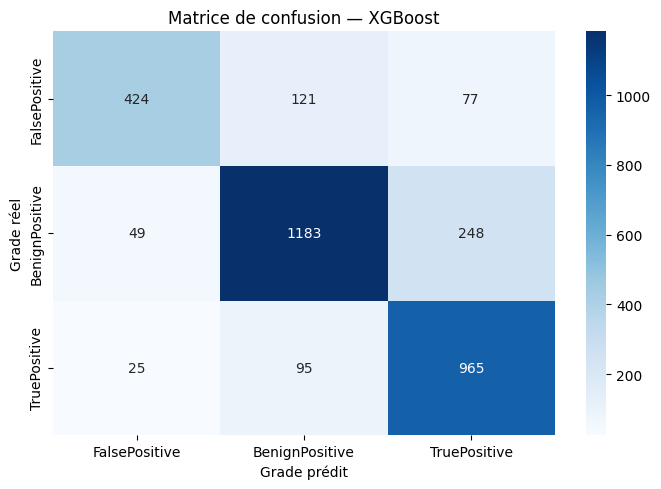

AUC-ROC XGBoost (macro OvR) : 0.948


In [29]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grade_names_list, yticklabels=grade_names_list, ax=ax)
ax.set_title('Matrice de confusion — XGBoost')
ax.set_ylabel('Grade réel')
ax.set_xlabel('Grade prédit')
plt.tight_layout()
plt.savefig(DATA_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# AUC multi-classe
auc_xgb = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f'AUC-ROC XGBoost (macro OvR) : {auc_xgb:.3f}')

## 4. Calcul du score de priorisation (0-100)

Le score présenté à l'analyste combine :
- La probabilité TP du modèle supervisé (principal)
- Le score d'anomalie Isolation Forest (secondaire, pour contexte)


In [30]:
# Score de priorisation : probabilité TP normalisée 0-100
proba_tp_test = y_proba[:, 2]  # colonne TP
priority_score = (proba_tp_test * 100).round(1)

# Définition des seuils (à ajuster selon la courbe PR)
# Ces seuils sont déterminés sur la courbe Precision-Recall
SEUIL_ACTION_URGENTE = 75
SEUIL_ESCALADE_N2 = 45
SEUIL_INVESTIGATION = 20
# < 20 → FP probable → clôture suggérée

def get_decision(score):
    if score >= SEUIL_ACTION_URGENTE:
        return 'ACTION_URGENTE'
    elif score >= SEUIL_ESCALADE_N2:
        return 'ESCALADE_N2'
    elif score >= SEUIL_INVESTIGATION:
        return 'INVESTIGATION_N1'
    else:
        return 'CLOTURE_FP'

decisions_test = np.array([get_decision(s) for s in priority_score])

print('Distribution des décisions suggérées :')
decision_counts = pd.Series(decisions_test).value_counts()
for dec, cnt in decision_counts.items():
    print(f'  {dec}: {cnt:,} ({cnt/len(decisions_test):.1%})')

# Validation des seuils
print('\nValidation des seuils (test set) :')
for decision in ['ACTION_URGENTE', 'ESCALADE_N2', 'INVESTIGATION_N1', 'CLOTURE_FP']:
    mask = decisions_test == decision
    if mask.sum() > 0:
        tp_rate = (y_test[mask] == 2).mean()
        fp_rate = (y_test[mask] == 0).mean()
        print(f'  {decision}: {mask.sum():,} incidents | TP={tp_rate:.1%} | FP={fp_rate:.1%}')

Distribution des décisions suggérées :
  CLOTURE_FP: 1,635 (51.3%)
  ACTION_URGENTE: 1,029 (32.3%)
  INVESTIGATION_N1: 284 (8.9%)
  ESCALADE_N2: 239 (7.5%)

Validation des seuils (test set) :
  ACTION_URGENTE: 1,029 incidents | TP=86.1% | FP=0.5%
  ESCALADE_N2: 239 incidents | TP=34.3% | FP=26.4%
  INVESTIGATION_N1: 284 incidents | TP=26.8% | FP=30.3%
  CLOTURE_FP: 1,635 incidents | TP=2.5% | FP=28.6%


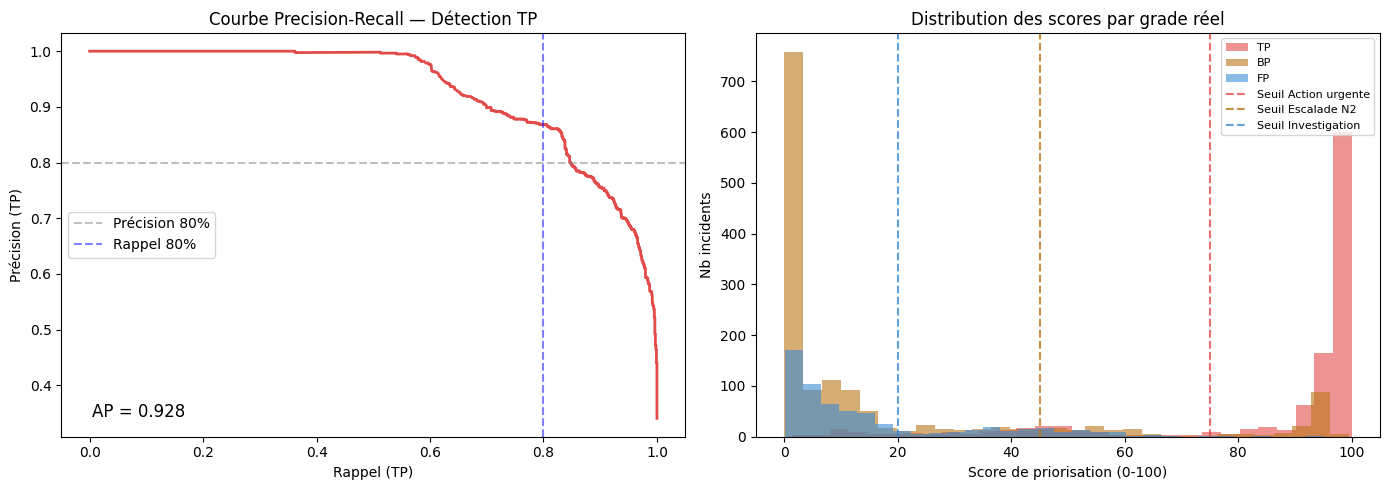

In [31]:
# Courbe Precision-Recall pour ajuster les seuils
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve pour TP
precision, recall, thresholds = precision_recall_curve((y_test == 2).astype(int), proba_tp_test)
axes[0].plot(recall, precision, color='#E24B4A', lw=2)
axes[0].axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Précision 80%')
axes[0].axvline(0.8, color='blue', linestyle='--', alpha=0.5, label='Rappel 80%')
axes[0].set_xlabel('Rappel (TP)')
axes[0].set_ylabel('Précision (TP)')
axes[0].set_title('Courbe Precision-Recall — Détection TP')
axes[0].legend()

ap = average_precision_score((y_test == 2).astype(int), proba_tp_test)
axes[0].text(0.05, 0.05, f'AP = {ap:.3f}', transform=axes[0].transAxes, fontsize=12)

# Distribution des scores par grade
for grade_code, grade_name, color in [(2,'TP','#E24B4A'), (1,'BP','#BA7517'), (0,'FP','#3B8BD4')]:
    mask = y_test == grade_code
    axes[1].hist(priority_score[mask], bins=30, alpha=0.6, label=grade_name, color=color)

# Lignes de seuils
for seuil, label, color in [
    (SEUIL_ACTION_URGENTE, 'Action urgente', '#E24B4A'),
    (SEUIL_ESCALADE_N2, 'Escalade N2', '#BA7517'),
    (SEUIL_INVESTIGATION, 'Investigation', '#3B8BD4')
]:
    axes[1].axvline(seuil, color=color, linestyle='--', alpha=0.8, label=f'Seuil {label}')

axes[1].set_xlabel('Score de priorisation (0-100)')
axes[1].set_ylabel('Nb incidents')
axes[1].set_title('Distribution des scores par grade réel')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'priority_scores.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Feature Importance globale

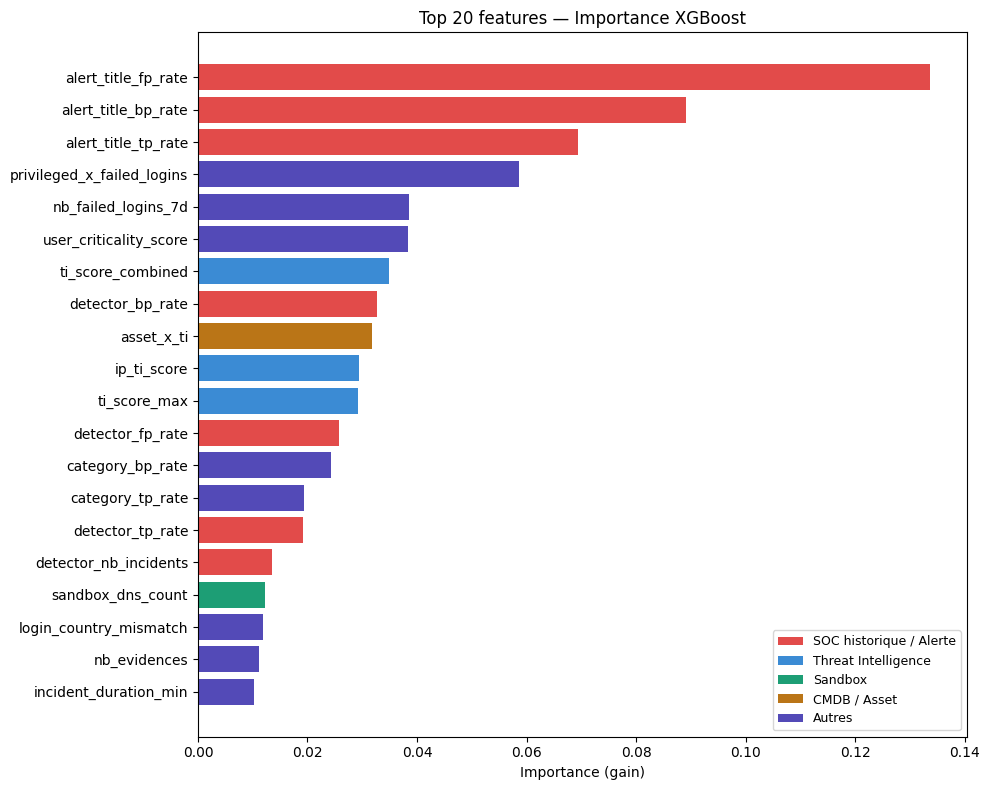

Top 10 features importantes :
alert_title_fp_rate           0.1338
alert_title_bp_rate           0.0892
alert_title_tp_rate           0.0694
privileged_x_failed_logins    0.0586
nb_failed_logins_7d           0.0385
user_criticality_score        0.0383
ti_score_combined             0.0350
detector_bp_rate              0.0328
asset_x_ti                    0.0317
ip_ti_score                   0.0294
dtype: float32


In [32]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_imp = importances.head(top_n)
colors_imp = ['#E24B4A' if 'detector' in c or 'alert_title' in c
               else '#3B8BD4' if 'ti_' in c or 'hash' in c or 'ip_' in c
               else '#1D9E75' if 'sandbox' in c
               else '#BA7517' if 'asset' in c
               else '#534AB7'
               for c in top_imp.index]
bars = ax.barh(range(top_n), top_imp.values, color=colors_imp)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_imp.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 20 features — Importance XGBoost')

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='SOC historique / Alerte'),
    Patch(facecolor='#3B8BD4', label='Threat Intelligence'),
    Patch(facecolor='#1D9E75', label='Sandbox'),
    Patch(facecolor='#BA7517', label='CMDB / Asset'),
    Patch(facecolor='#534AB7', label='Autres'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importance_xgb.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features importantes :')
print(importances.head(10).round(4))

## 6. Simulation du feedback loop (théorique)

**Concept** : après validation par l'analyste, les décisions corrigées enrichissent le dataset d'entraînement. On simule ici l'amélioration attendue sur 3 cycles.

=== Simulation du Feedback Loop ===

Principe : l'analyste valide ou corrige la décision suggérée.
Ces corrections deviennent de nouveaux labels pour réentraîner le modèle.

Cycle 1 (2,681 feedbacks) → F2-score : 0.817
Cycle 2 (6,703 feedbacks) → F2-score : 0.819
Cycle 3 (13,406 feedbacks) → F2-score : 0.817


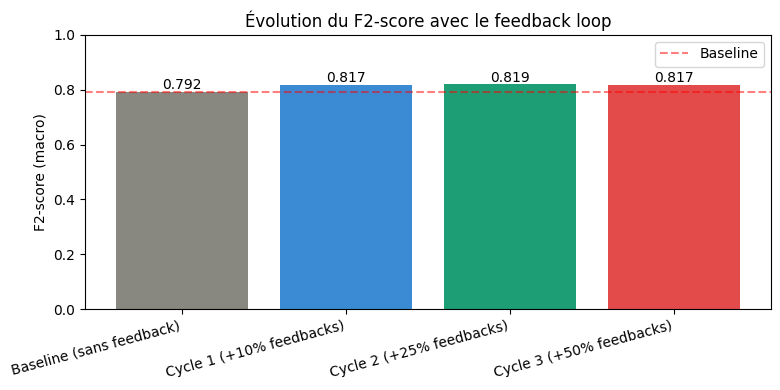

In [33]:
print('=== Simulation du Feedback Loop ===\n')
print('Principe : l\'analyste valide ou corrige la décision suggérée.')
print('Ces corrections deviennent de nouveaux labels pour réentraîner le modèle.\n')

# Simulation : on prend un sous-ensemble du test comme "feedbacks validés"
# et on montre l'amélioration du F2-score

results_feedback = []
f2_baseline = fbeta_score(y_test, y_pred, beta=2, average='macro')
results_feedback.append({'cycle': 0, 'type': 'Baseline (sans feedback)',
                          'n_feedback': 0, 'f2_score': f2_baseline})

for cycle, feedback_pct in enumerate([0.1, 0.25, 0.5], 1):
    n_feedback = int(len(X_train) * feedback_pct)
    # Simuler l'ajout de n_feedback nouveaux exemples labellisés
    np.random.seed(RANDOM_SEED + cycle)
    feedback_idx = np.random.choice(len(X_test),
                                     size=min(n_feedback, len(X_test)//2),
                                     replace=False)

    X_train_aug = np.vstack([X_train_sm, X_test[feedback_idx]])
    y_train_aug = np.concatenate([y_train_sm, y_test[feedback_idx]])

    # Réentraînement rapide
    # NOTE METHODOLOGIQUE — le cycle 0 (baseline) correspond à xgb_model
    # (max_depth=5, sample_weight). Les cycles 1-3 réentraînent xgb_aug avec
    # max_depth=6 et sans pondération : ce qui change entre cycle 0 et cycle 1
    # n'est donc PAS seulement l'ajout d'incidents, mais aussi les
    # hyperparamètres. Par ailleurs les "feedbacks" sont simulés (incidents du
    # test set réutilisés), pas de vrais retours analystes.
    # La simulation illustre la TENDANCE du feedback loop — le F2 progresse
    # quand le volume qualifié augmente — sans prétendre isoler la contribution
    # exacte des données. Un protocole strictement comparatif (hyperparamètres
    # identiques cycle 0 → cycle N) constituerait une amélioration.
    # L'objectif est de montrer que le feedback loop a un potentiel d'amélioration du F2.
    xgb_aug = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        objective='multi:softprob', num_class=3,
        random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
    )
    xgb_aug.fit(X_train_aug, y_train_aug)
    y_pred_aug = xgb_aug.predict(X_test)
    f2_aug = fbeta_score(y_test, y_pred_aug, beta=2, average='macro')

    results_feedback.append({
        'cycle': cycle,
        'type': f'Cycle {cycle} (+{feedback_pct:.0%} feedbacks)',
        'n_feedback': n_feedback,
        'f2_score': f2_aug
    })
    print(f'Cycle {cycle} ({n_feedback:,} feedbacks) → F2-score : {f2_aug:.3f}')

results_df = pd.DataFrame(results_feedback)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['type'], results_df['f2_score'],
       color=['#888780', '#3B8BD4', '#1D9E75', '#E24B4A'])
ax.set_ylim(0, 1)
ax.set_ylabel('F2-score (macro)')
ax.set_title('Évolution du F2-score avec le feedback loop')
ax.axhline(f2_baseline, color='red', linestyle='--', alpha=0.5, label='Baseline')
ax.legend()
plt.xticks(rotation=15, ha='right')
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(i, row['f2_score'] + 0.01, f'{row["f2_score"]:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / 'feedback_loop_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Génération du fichier de prédictions pour la démo Streamlit

In [ ]:
DEMO_SIZE = 500

# ── Chargement des colonnes d'affichage depuis incidents_dataset ──────────────
# Ces colonnes ne sont pas dans features_ml (supprimées en 02_)
# mais nécessaires pour l'affichage dans la démo Streamlit
incidents_ds = pd.read_csv(DATA_DIR / 'incidents_dataset.csv',
                            dtype={'sample_device_id': str})

DISPLAY_COLS = ['IncidentId', 'top_alert_title', 'top_category', 'first_seen',
                'nb_alerts', 'sample_ip', 'sample_device_id', 'sample_device',
                'sample_account', 'sample_sha256', 'IncidentGrade']

# ── Prédictions sur TOUS les incidents (train + test) ────────────────────────
# Architecture SOC réelle : le modèle score tous les incidents du datalake,
# pas seulement le test set. Le sample de 500 pour la démo est extrait
# depuis ce fichier complet — la démo n'intervient qu'en 05_.

# Scores XGBoost sur tout le dataset
y_proba_full = xgb_model.predict_proba(X)       # X = tous les 30 000 incidents
y_pred_full  = xgb_model.predict(X)
priority_score_full = (y_proba_full[:, 2] * 100).round(1)
decisions_full = np.array([get_decision(s) for s in priority_score_full])

# Scores Isolation Forest sur tout le dataset
anomaly_scores_full = iso_forest.decision_function(X)
iso_score_full = (100 - scaler_iso.transform(
    anomaly_scores_full.reshape(-1, 1)
).flatten() * 100).round(1)

# ── Construction de predictions_full.csv ─────────────────────────────────────
predictions_full = df[['IncidentId', 'OrgId']].copy().reset_index(drop=True)

# Enrichissement depuis incidents_dataset
predictions_full = predictions_full.merge(
    incidents_ds[DISPLAY_COLS], on='IncidentId', how='left'
)

# Scores et décisions
predictions_full['priority_score']     = priority_score_full
predictions_full['iso_anomaly_score']  = iso_score_full
predictions_full['proba_fp']           = (y_proba_full[:, 0] * 100).round(1)
predictions_full['proba_bp']           = (y_proba_full[:, 1] * 100).round(1)
predictions_full['proba_tp']           = (y_proba_full[:, 2] * 100).round(1)
predictions_full['decision_suggested'] = decisions_full
predictions_full['grade_reel']         = y
predictions_full['grade_reel_label']   = predictions_full['grade_reel'].map(
    {2: 'TruePositive', 1: 'BenignPositive', 0: 'FalsePositive'})
predictions_full['prediction_label']   = pd.Series(y_pred_full).map(
    {2: 'TruePositive', 1: 'BenignPositive', 0: 'FalsePositive'}).values

def get_severity(score):
    if score >= 75:   return 'CRITIQUE'
    elif score >= 45: return 'HAUTE'
    elif score >= 20: return 'MOYENNE'
    else:             return 'FAIBLE'

predictions_full['severity'] = predictions_full['priority_score'].apply(get_severity)

# ── Validation sur le test set (métriques officielles) ───────────────────────
# On évalue sur le test set uniquement pour avoir des métriques non biaisées
# (le modèle n'a pas vu le test set pendant l'entraînement)
test_mask = df.index.isin(test_idx)
pred_test = predictions_full[test_mask].copy()

print('=== Validation sur le test set (métriques non biaisées) ===')
print(f'Test set : {test_mask.sum():,} incidents')
print(f'\nDistribution des décisions (test) :')
print(pred_test['decision_suggested'].value_counts())
print(f'\nValidation des seuils (test) :')
for decision in ['ACTION_URGENTE', 'ESCALADE_N2', 'INVESTIGATION_N1', 'CLOTURE_FP']:
    mask = pred_test['decision_suggested'] == decision
    if mask.sum() > 0:
        tp_rate = (pred_test.loc[mask, 'grade_reel'] == 2).mean()
        fp_rate = (pred_test.loc[mask, 'grade_reel'] == 0).mean()
        print(f'  {decision}: {mask.sum():,} incidents | TP={tp_rate:.1%} | FP={fp_rate:.1%}')

# ── Métriques ROI sur le dataset complet ─────────────────────────────────────
# ATTENTION — chiffres indicatifs, NON utilisés comme métriques de performance.
# Ce bloc calcule la précision/rappel sur les 30 000 incidents, donc INCLUT les
# 26 813 incidents du train set que le modèle a déjà vus pendant l'entraînement.
# La précision affichée ici (~94 %) est mécaniquement optimiste (overfitting train).
# La métrique de performance officielle du POC est celle du TEST SET ci-dessus :
# ACTION_URGENTE = 86,1 % de précision (cellule 17 et bloc "Validation test set").
# Métrique officielle du POC = TEST SET (86,1 %) — pas le train set (94 %, overfitting).
print('\n=== Métriques ROI (dataset complet) ===')
au = predictions_full[predictions_full['decision_suggested'] == 'ACTION_URGENTE']
total_tp = (predictions_full['grade_reel'] == 2).sum()
tp_in_au = (au['grade_reel'] == 2).sum()
print(f"ACTION_URGENTE : {len(au):,} incidents ({len(au)/len(predictions_full):.1%} du volume)")
print(f"  → Précision : {tp_in_au/len(au):.1%} de vrais positifs")
print(f"  → Rappel   : {tp_in_au/total_tp:.1%} des TP capturés")

# ── Extraction du sample de 500 pour la démo ─────────────────────────────────
# Stratification sur decision_suggested pour avoir toutes les décisions représentées
# On exclut les incidents du train set pour la démo (évite l'overfitting apparent)
pred_test_only = predictions_full[test_mask].reset_index(drop=True)

demo_sample = (
    pred_test_only
    .groupby('decision_suggested', group_keys=False)
    .apply(
        lambda g: g.sample(
            min(len(g), int(DEMO_SIZE * len(g) / len(pred_test_only)) + 5),
            random_state=RANDOM_SEED
        )
    )
    .sample(DEMO_SIZE, random_state=RANDOM_SEED)
    .sort_values('priority_score', ascending=False)
    .reset_index(drop=True)
)

# ── Sauvegardes ───────────────────────────────────────────────────────────────
predictions_full.to_csv(DATA_DIR / 'predictions_full.csv', index=False)
demo_sample.to_csv(DATA_DIR / 'predictions_sample.csv', index=False)

# Sauvegardes — deux formats pour compatibilité pipeline
xgb_model.get_booster().save_model(str(MODEL_DIR / 'xgboost_booster.json'))  # booster natif pour 04_
joblib.dump(xgb_model, MODEL_DIR / 'xgboost_model.pkl')      # wrapper pour inférence
print('✅ xgboost_booster.json : booster natif XGBoost')
print('✅ xgboost_model.pkl    : wrapper pipeline')

# Config d'inférence pour déploiement production
inference_config = {
    'feature_cols':   FEATURE_COLS,
    'global_rates':   global_rates,
    'grade_map':      {0: 'FalsePositive', 1: 'BenignPositive', 2: 'TruePositive'},
    'seuils': {
        'ACTION_URGENTE':   SEUIL_ACTION_URGENTE,
        'ESCALADE_N2':      SEUIL_ESCALADE_N2,
        'INVESTIGATION_N1': SEUIL_INVESTIGATION,
    }
}
with open(MODEL_DIR / 'inference_config.pkl', 'wb') as f:
    pickle.dump(inference_config, f)

print(f'\n✅ predictions_full.csv    : {len(predictions_full):,} incidents (dataset complet)')
print(f'✅ predictions_sample.csv  : {len(demo_sample):,} incidents (démo — test set uniquement)')
print(f'✅ xgboost_model.pkl       : modèle XGBoost')
print(f'✅ inference_config.pkl    : config complète pour l\'inférence SIEM')
print(f'\nDistribution dans la démo :')
print(demo_sample['decision_suggested'].value_counts())
print('\n→ Prochaine étape : 04_xai.ipynb')

=== Validation sur le test set (métriques non biaisées) ===
Test set : 3,187 incidents

Distribution des décisions (test) :
decision_suggested
CLOTURE_FP          1635
ACTION_URGENTE      1029
INVESTIGATION_N1     284
ESCALADE_N2          239
Name: count, dtype: int64

Validation des seuils (test) :
  ACTION_URGENTE: 1,029 incidents | TP=86.1% | FP=0.5%
  ESCALADE_N2: 239 incidents | TP=34.3% | FP=26.4%
  INVESTIGATION_N1: 284 incidents | TP=26.8% | FP=30.3%
  CLOTURE_FP: 1,635 incidents | TP=2.5% | FP=28.6%

=== Métriques ROI (dataset complet) ===
ACTION_URGENTE : 4,743 incidents (15.8% du volume)
  → Précision : 94.2% de vrais positifs
  → Rappel   : 67.5% des TP capturés
✅ xgboost_booster.json : booster natif XGBoost
✅ xgboost_model.pkl    : wrapper pipeline

✅ predictions_full.csv    : 30,000 incidents (dataset complet)
✅ predictions_sample.csv  : 500 incidents (démo — test set uniquement)
✅ xgboost_model.pkl       : modèle XGBoost
✅ inference_config.pkl    : config complète pour l

/var/folders/fb/n81c_xk9361bflkbqt783n_00000gn/T/ipykernel_31556/1413346908.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
